# Packages Instalment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.neighbors import KernelDensity
import scipy.stats as stats
from scipy.stats import iqr
import math

# Kernel Function Overview

In [2]:
# Kernel function definitions
def gaussian_kernel(x):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x**2)

def epanechnikov_kernel(x):
    return 0.75 * (1 - x**2) * (np.abs(x) <= 1)

def rectangular_kernel(x):
    return 0.5 * (np.abs(x) <= 1)

def biweight_kernel(x):
    return (15 / 16) * (1 - x**2)**2 * (np.abs(x) <= 1)

def cosine_kernel(x):
    return (np.pi / 4) * np.cos(np.pi * x / 2) * (np.abs(x) <= 1)

kernels = {
    "Gaussian Kernel": gaussian_kernel,
    "Epanechnikov Kernel": epanechnikov_kernel,
    "Rectangular Kernel": rectangular_kernel,
    "Biweight Kernel": biweight_kernel,
    "Cosine Kernel": cosine_kernel,
}

colours = {
    "Gaussian Kernel": "#A86A9D",
    "Epanechnikov Kernel": "#FBCB1F",
    "Rectangular Kernel": "#1C6AB1",
    "Biweight Kernel": "#ED4043",
    "Cosine Kernel": "#008C8C",
}

In [3]:
# Visualise the shape of different kernel functions
def plot_kernels(kernels, colours = None):
    x = np.linspace(-2, 2, 200)

    plt.figure(figsize = (6, 4))

    for kernel_name, kernel_func in kernels.items():
        y = kernel_func(x)
        colour = colours.get(kernel_name) if colours else None
        plt.plot(x, y, label = kernel_name, color = colour)

    plt.xlabel("t")
    plt.ylabel("Kernel Value")
    plt.title("Shapes of Different Kernel Functions", pad = 20)
    plt.legend(fontsize="small")
    plt.show()

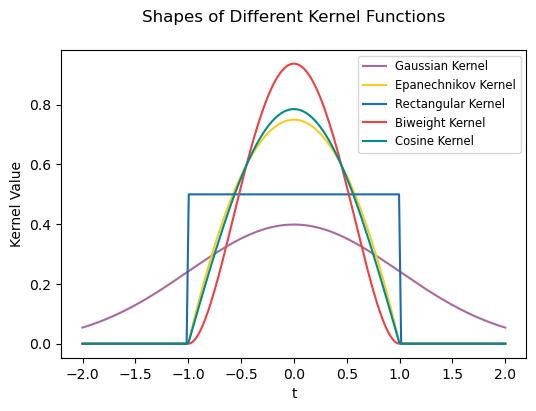

In [4]:
plot_kernels(kernels, colours = colours)

# Bandwidth Parameter Comparison

In [5]:
# Plot kernel function using different bandwidth parameters
def plot_kde_bandwidths(data, bandwidths, kernel = "gaussian"):
    data = np.asarray(data)[:, np.newaxis] # KernelDensity expects 2D inputs
    x_grid = np.linspace(-3, 3, 1000)[:, np.newaxis] 
    colours = ["#F0776D", "#29B4B6", "#0D95EC"]

    plt.figure(figsize = (6, 4))

    for i, bandwidth in enumerate(bandwidths):
        kde = KernelDensity(kernel = kernel, bandwidth = bandwidth).fit(data)
        log_density = kde.score_samples(x_grid) # Log estimated density
        plt.plot(
            x_grid[:, 0],
            np.exp(log_density),
            label = f"Bandwidth = {bandwidth}",
            color = colours[i % len(colours)]
        )

    plt.hist(data[:, 0], bins = 30, density = True, alpha = 0.5,
             label = "Histogram", color = "#C5CCDB")

    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.title("KDE with Different Bandwidths", pad = 20)
    plt.legend()
    plt.show()

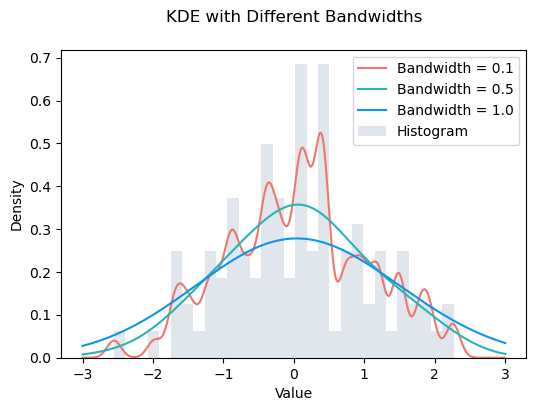

In [6]:
np.random.seed(0)
data = np.random.normal(0, 1, 100)

plot_kde_bandwidths(data, [0.1, 0.5, 1.0])

# Data Preprocessing

In [7]:
# --- IMPORTANT: DATA LOADING ---
# Note: 'carbon_price.csv' is not uploaded due to data privacy/size constraints.
# This code is for demonstration only.
try:
    carbon_data = pd.read_csv('carbon_price.csv')
except FileNotFoundError:
    print("Please provide 'carbon_price.csv' to run the analysis.")
    carbon_data = pd.DataFrame(columns=['PX_LAST', 'PX_VOLUME']) 

carbon_data.rename(columns = {'PX_LAST':'Price'}, inplace = True)
carbon_data = carbon_data.drop(columns = ['PX_VOLUME'])

In [8]:
carbon_data.head()

,Date,Price
0,16/05/2024,70.10
1,15/05/2024,69.46
2,14/05/2024,70.22
3,13/05/2024,69.81
4,10/05/2024,71.91


In [9]:
print("Number of missing data in each column:")
print(carbon_data.isnull().sum().to_string())
print("\nNumber of duplicated data:", carbon_data.duplicated().sum())

Number of missing data in each column:
Date     0
Price    0

Number of duplicated data: 0


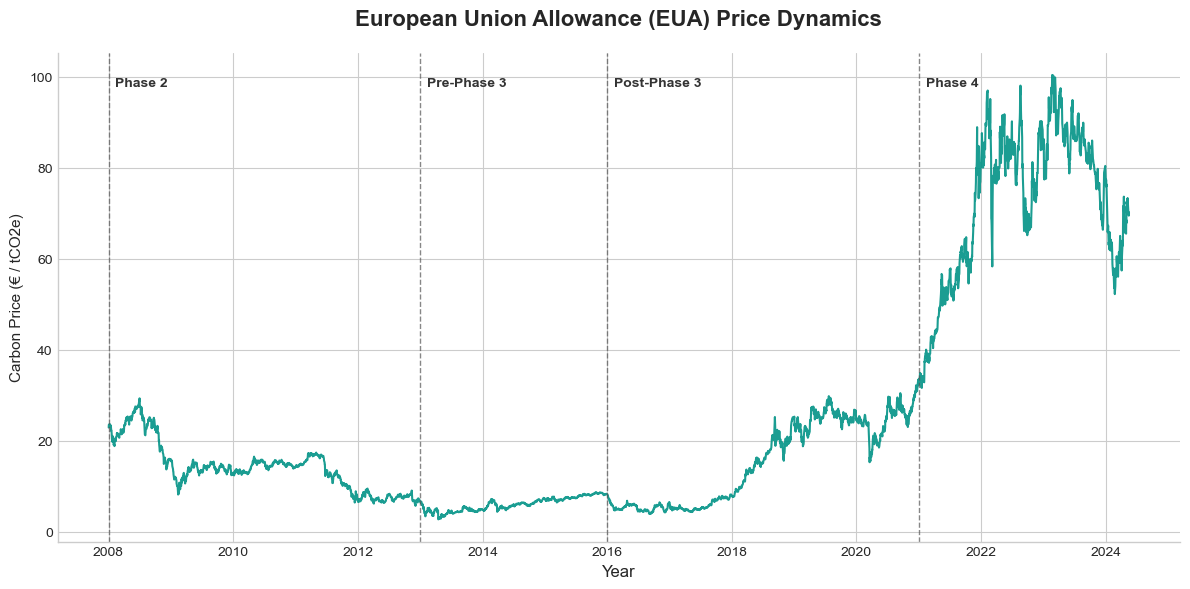

In [10]:
# Visualise the overall dynamics of the carbon price data
carbon_data['Date'] = pd.to_datetime(carbon_data['Date'], format = '%d/%m/%Y')
carbon_data = carbon_data[carbon_data['Date'] >= '2008-01-01'].sort_values('Date') # Start from the second phase

plt.figure(figsize = (12, 6), dpi = 100)
plt.style.use('seaborn-v0_8-whitegrid') 

plt.plot(carbon_data['Date'], carbon_data['Price'], color = '#029386', linewidth = 1.5, 
         label = 'EUA Price', alpha = 0.9)

# Define phase boundaries for data partitioning
# These dates represent the 'start' of each EU ETS policy period
phases = [
    ('2008-01-01', 'Phase 2'),
    ('2013-01-01', 'Pre-Phase 3'),
    ('2016-01-01', 'Post-Phase 3'),
    ('2021-01-01', 'Phase 4'),
]

offset = pd.Timedelta(days = 40)
for date, phase in phases:
    date = pd.to_datetime(date)
    plt.axvline(date, color = '#555555', linestyle = '--', linewidth = 1, alpha = 0.7)

    plt.text(date + offset, plt.ylim()[1] * 0.95, phase, verticalalignment = 'top', 
             horizontalalignment = 'left', fontsize = 10, color = '#333333', fontweight = 'bold')

# Set year locator every two years
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y')) # Only 'year'
    
plt.title('European Union Allowance (EUA) Price Dynamics', fontsize = 16, fontweight = 'bold', pad = 20)
plt.xlabel('Year', fontsize = 12)
plt.ylabel('Carbon Price (€ / tCO2e)', fontsize = 11)
    
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)    
plt.tight_layout()
plt.show()

# Segment the dataset

Data collection was finalised on 16 May 2024. Consequently, this date serves as the upper temporal bound for the analysis.  
The dataset was categorized into four distinct EU ETS regulatory phases:  
- Phase 2: 2008 - 2012
- Pre-Phase 3: 2013 - 2015 (Introduction of the Market Stability Reserve)
- Post-Phase 3: 2016-2020
- Phase 4: 2021-2024

In [11]:
# Extract bin boundaries and labels from 'phases'
    
bins = [pd.to_datetime(date) for date, _ in phases]
labels = [phase for _, phase in phases]

# Ensure the lastest records are captured
bins.append(carbon_data['Date'].max() + pd.Timedelta(days = 1))

# Vectorised binning
carbon_data['Phase'] = pd.cut(carbon_data['Date'], bins = bins, labels = labels, right = False)

In [12]:
print(carbon_data[['Date', 'Phase']].head())

           Date    Phase
4215 2008-01-02  Phase 2
4214 2008-01-03  Phase 2
4213 2008-01-04  Phase 2
4212 2008-01-07  Phase 2
4211 2008-01-08  Phase 2


In [13]:
# Display a sample to verify correct phase assignment at transition points
print(carbon_data.groupby('Phase')['Date'].agg(['min', 'max']))

                    min        max
Phase                             
Phase 2      2008-01-02 2012-12-31
Pre-Phase 3  2013-01-02 2015-12-31
Post-Phase 3 2016-01-04 2020-12-31
Phase 4      2021-01-04 2024-05-16


# Boxplots of Carbon Returns

In [14]:
carbon_data['Returns'] = carbon_data['Price'].pct_change()
carbon_data.dropna(inplace = True)

In [15]:
print(carbon_data.head(10))

           Date  Price    Phase   Returns
4214 2008-01-03  23.54  Phase 2  0.027051
4213 2008-01-04  23.55  Phase 2  0.000425
4212 2008-01-07  23.66  Phase 2  0.004671
4211 2008-01-08  23.70  Phase 2  0.001691
4210 2008-01-09  23.42  Phase 2 -0.011814
4209 2008-01-10  23.11  Phase 2 -0.013237
4208 2008-01-11  23.11  Phase 2  0.000000
4207 2008-01-14  23.41  Phase 2  0.012981
4206 2008-01-15  23.17  Phase 2 -0.010252
4205 2008-01-16  22.75  Phase 2 -0.018127


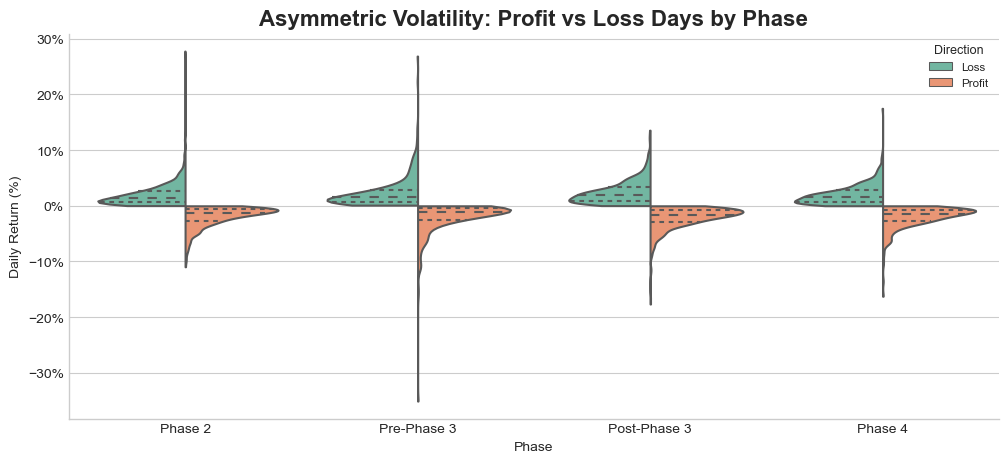

In [16]:
# Label daily returns as 'Profit' (Positive) or 'Loss' (Negative or 0)
carbon_data['Direction'] = carbon_data['Returns'].apply(lambda x: 'Loss' if x > 0 else 'Profit')

# Generate a split violin plot to analyse return asymmetry across regulatory phases
plt.figure(figsize = (12, 5))

sns.violinplot(
    data = carbon_data, 
    x = 'Phase', 
    y = 'Returns', 
    hue = 'Direction', 
    split = True,
    inner = 'quartile', 
    palette = 'Set2',
    cut = 0
)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) # 1.0 represents 100%

plt.title('Asymmetric Volatility: Profit vs Loss Days by Phase', fontsize = 16, fontweight = 'bold')
plt.ylabel('Daily Return (%)')
plt.legend(title='Direction', fontsize='small', title_fontsize='9')
sns.despine()
plt.show()

> **Note**: To ensure a conservative risk assessment, zero-return days were classified as **Loss** (non-profitable), reflecting the opportunity cost relative to risk-free investments (e.g., bonds).

# Descriptive Statistics

In [17]:
# Calculate all metrics including higher-order moments
def summ_stats(phase):
    return pd.Series({
        'Count': phase.count(),
        'Mean': phase.mean(),
        'Std Dev': phase.std(),
        'Min': phase.min(),
        'Max': phase.max(),
        'Skewness': phase.skew(),        
        'Kurtosis': phase.kurtosis() + 3  # Pearson's Kurtosis (Gaussian distribution = 3)
    })


# .unstack() transforms metrics into columns
# .T transposes the table for better readability
desc_stats = carbon_data.groupby('Phase')['Returns'].apply(summ_stats).unstack().T

# Force Count to show as integer, others as 6-decimal floats
print("Descriptive Statistics of EUA Returns by Regulatory Phase:\n")
display(desc_stats.style.format(lambda x: f"{x:.0f}" if x.is_integer() else f"{x:.6f}"))

Descriptive Statistics of EUA Returns by Regulatory Phase:



Phase,Phase 2,Pre-Phase 3,Post-Phase 3,Phase 4
Count,1285,774,1287,869
Mean,-0.000588,0.000967,0.001542,0.001258
Std Dev,0.027425,0.036557,0.030790,0.027550
Min,-0.109551,-0.350840,-0.176471,-0.162511
Max,0.277937,0.269006,0.135857,0.175129
Skewness,0.724378,-0.524300,-0.074238,-0.208949
Kurtosis,12.459946,20.805459,5.645240,7.226922


# Quantile-Quantile Plots

In [18]:
def qq_plot(df, phases, phase_labels, value_col = 'Returns', phase_col = 'Phase', ncols = 2):
    """
    Generate an automated grid of Q-Q Plots to analyse heavy-tailed distributions.
    
    Parameters:
        df (pd.DataFrame): The input dataset containing returns and phase categories.
        phases (list of str): A list defining the specific phases and their display order.
        phase_labels (dict): A mapping of phase keys (str) to descriptive titles (str).
        value_col (str, optional): The column name for numerical returns. Defaults to 'Returns'.
        phase_col (str, optional): The column name for grouping phases. Defaults to 'Phase'.
        ncols (int, optional): Number of columns in the subplot grid. Defaults to 2.
        
    Returns:
        None: This function generates a Matplotlib figure directly.
    """
    sns.set_style("ticks")
    num_phases = len(phases)
    nrows = math.ceil(num_phases / ncols)
    
    # Adjust figure size dynamically based on the number of rows/cols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    
   # Ensure axes is always a list-like object for iteration
    if num_phases > 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    for i, phase_name in enumerate(phases):
        
        phase_data = df[df[phase_col] == phase_name][value_col].dropna()
        
        # Q-Q plots
        stats.probplot(phase_data, dist = "norm", plot = axes_flat[i])
        
        # .get_lines() returns a list [scatter plot, baseline]
        objects = axes_flat[i].get_lines()
        objects[0].set(markerfacecolor = 'none', markeredgecolor = '#C5CCDB', markersize = 5, alpha = 0.8)
        objects[1].set(color = '#25A795', linewidth = 2)
        
        axes_flat[i].grid(False)
        axes_flat[i].set_title(phase_labels.get(phase_name, phase_name), fontsize = 12)
        axes_flat[i].set_xlabel('Normal Theoretical Quantiles', fontsize = 10)
        axes_flat[i].set_ylabel('The EUA Returns Quantiles', fontsize = 10)

    # Hide any unused subplots
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')
        
    plt.tight_layout()
    plt.suptitle('Quantile-Quantile Analysis: EUA Returns vs. Normal Distribution', 
                 fontsize = 16, y = 1.02, fontweight = 'bold')
    plt.show()

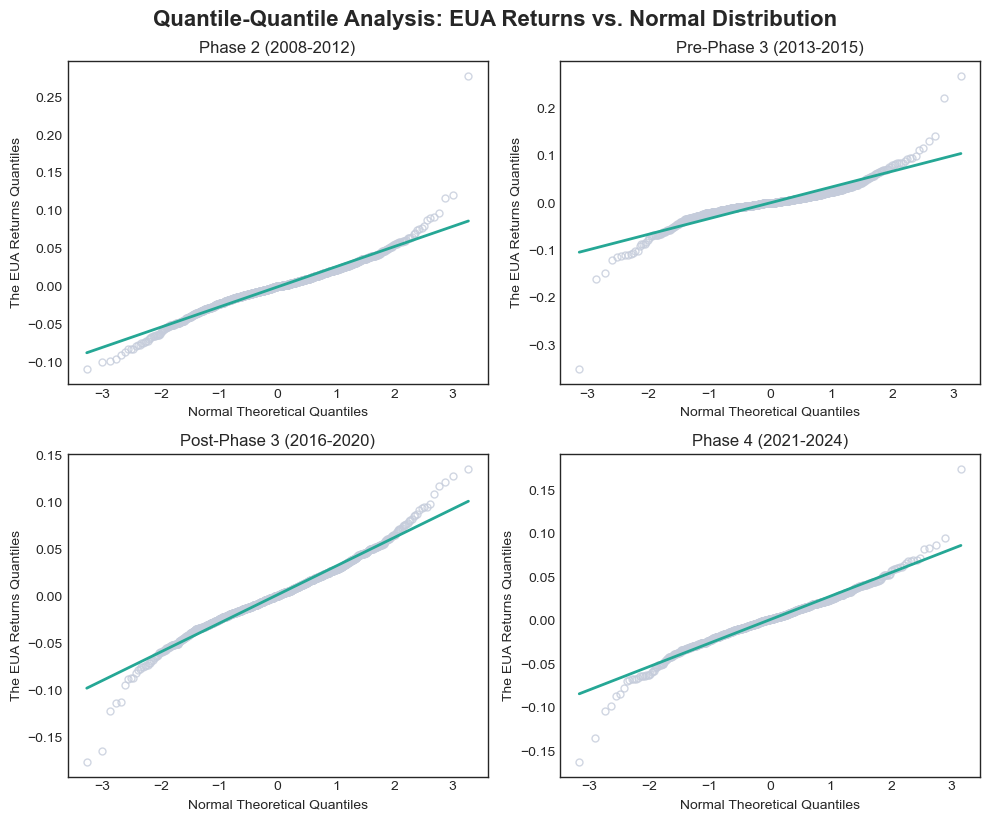

In [19]:
phases = ['Phase 2', 'Pre-Phase 3', 'Post-Phase 3', 'Phase 4']
labels = {
    'Phase 2': 'Phase 2 (2008-2012)',
    'Pre-Phase 3': 'Pre-Phase 3 (2013-2015)', 
    'Post-Phase 3': 'Post-Phase 3 (2016-2020)',
    'Phase 4': 'Phase 4 (2021-2024)'
}

qq_plot(carbon_data, phases, labels)

>**Note:** The QQ plots exhibited significant upward curvature in the upper quantiles across all phases, confirming that EUA returns were leptokurtic (fat-tailed) and deviated from normality. This justified the necessity of using a non-parametric KDE approach to capture extreme tail risks.

# Histogram

In [22]:
def plot_histograms(df, phases, phase_labels, value_col = 'Returns', phase_col = 'Phase', ncols = 2, bins = 30):
    """
    Generate histograms to visualise data distribution across phases.

    Parameters:
        df (pd.DataFrame): The input dataset (e.g., carbon_data).
        phases (list of str): The specific phases to plot, defining the grid order.
        phase_labels (dict): Mapping of phase keys to descriptive titles with years.
        value_col (str, optional): The numerical column to plot. Defaults to 'Returns'.
        phase_col (str, optional): The categorical column for grouping. Defaults to 'Phase'.
        ncols (int, optional): Number of columns in the grid. Defaults to 2.
        bins (int, optional): Number of bins for the histogram. Defaults to 30.

    Returns:
        None: This function generates a Matplotlib figure directly.
    """
    sns.axes_style("ticks")
    num_phases = len(phases)
    nrows = math.ceil(num_phases / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize = (5 * ncols, 4 * nrows))
    axes_flat = axes.flatten() if num_phases > 1 else [axes]

    for i, phase_name in enumerate(phases):

        phase_data = df[df[phase_col] == phase_name][value_col].dropna()
        
        sns.histplot(phase_data, color = '#80A481', ax = axes_flat[i], 
                     kde = False, bins = bins, edgecolor = 'black', alpha = 0.7)
        
        axes_flat[i].grid(False)
        axes_flat[i].set_title(phase_labels.get(phase_name, phase_name), fontsize = 12)
        axes_flat[i].set_xlabel('Returns', fontsize = 10)
        axes_flat[i].set_ylabel('Count', fontsize = 10)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.suptitle('Distribution Analysis: Histograms of EUA Returns by Phase', 
                 fontsize = 16, y = 1.02, fontweight = 'bold')
    plt.show()

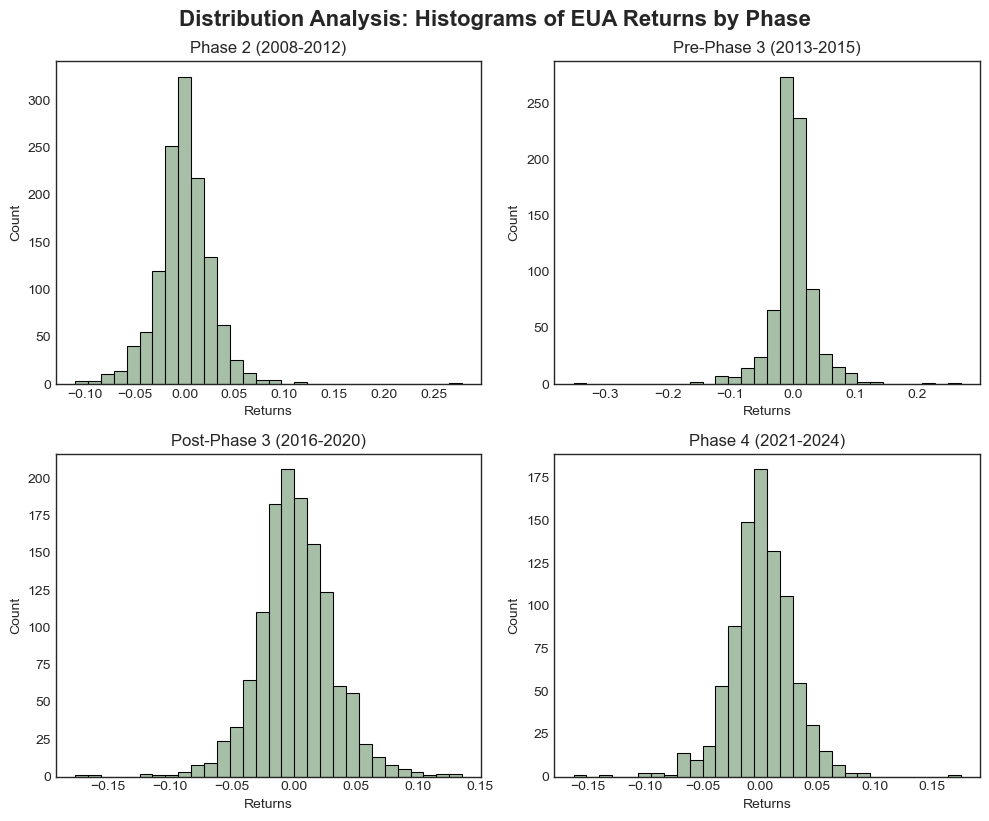

In [23]:
plot_histograms(carbon_data, phases,labels)

# Right Tails

In [25]:
def extract_right_tails(df, phases, percentile = 90, value_col = 'Returns', phase_col = 'Phase'):
    """
    Extract extreme observations and their corresponding threshold values.

    Parameters:
        df (pd.DataFrame): The full dataset (carbon_data).
        phases (list): Ordered list of phases to analyse.
        percentile (int): The threshold percentile (e.g., 90 for top 10%).
        value_col (str): Column name for returns.
        phase_col (str): Column name for phases.

    Returns:
        tuple: (pd.DataFrame, pd.Series)
            - The first element is the filtered DataFrame (Right Tails).
            - The second element is a Series of the thresholds used for each phase.
    """
    tail_data = []
    thresholds = {}

    for phase in phases:
        phase_data = df[df[phase_col] == phase]
        
        threshold = phase_data[value_col].quantile(percentile / 100)
        thresholds[phase] = threshold
        
        # Filter the data greater than threshold 
        right_tail = phase_data[phase_data[value_col] > threshold].copy()
        tail_data.append(right_tail)
        
        # Combine tail data of each phase
        combined_data = pd.concat(tail_data, axis = 0)
        threshold_series = pd.Series(thresholds, name=f"{percentile}th_Threshold")
    
    return combined_data, threshold_series

In [26]:
# Unpacking
extreme_returns_df, phase_thresholds = extract_right_tails(carbon_data, phases)

print("1. 90th Percentile of Each Phase:\n")
print(phase_thresholds)

print("\n2. Right-Tail Return Data:")
display(extreme_returns_df.head())

1. 90th Percentile of Each Phase:

Phase 2         0.029746
Pre-Phase 3     0.033636
Post-Phase 3    0.038317
Phase 4         0.032463
Name: 90th_Threshold, dtype: float64

2. Right-Tail Return Data:


,Date,Price,Phase,Returns,Direction
4198,2008-01-25,21.04,Phase 2,0.064777,Loss
4190,2008-02-06,19.97,Phase 2,0.059979,Loss
4184,2008-02-14,20.72,Phase 2,0.039639,Loss
4181,2008-02-19,21.64,Phase 2,0.033923,Loss
4152,2008-04-02,23.42,Phase 2,0.039964,Loss


# Kernel Density Estimation

In [27]:
def plot_right_tail_kde(tail_df, phases, phase_labels, ncols = 2):
    """
    Perform Kernel Density Estimation (KDE) with Sheather-Jones optimal bandwidth
    for right-tail distributions.

    Parameters:
        tail_df (pd.DataFrame): The filtered extreme returns data.
        phases (list): List of phases to plot.
        phase_labels (dict): Mapping for subplot titles.
        ncols (int): Number of columns in the grid.

    Returns:
        tuple: (bandwidth_results, density_results)
        - bandwidth_results (dict): Contains 'Silverman' and 'Sheather-Jones' bandwidths 
          for each phase.
        - density_results (dict): Contains 'x_grid', 'density_est', and the final 
          'bandwidth' used for plotting.
    """
    num_phases = len(phases)
    nrows = math.ceil(num_phases / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize = (5 * ncols, 4 * nrows))
    axes_flat = axes.flatten() if num_phases > 1 else [axes]
    
    # Constants for Gaussian Kernel
    R_K = 1 / (2 * math.sqrt(math.pi))
    density_results = {}
    bandwidth_results = {}

    for i, phase_name in enumerate(phases):
        # Transfer data into a 2D array
        data = tail_df[tail_df['Phase'] == phase_name]['Returns'].values.reshape(-1, 1)
        n = len(data)
        
        # Skip plotting if no data is available
        if n == 0: continue
        
        # Silverman's rule of thumb (pilot bandwidth)
        pilot_bdw = 0.9 * min(np.std(data), iqr(data) / 1.34) * n ** (-1 / 5.)
        
        # Grids Setting
        min_val, max_val = data.min(), data.max()
        grid_min = min_val - 0.1 * (max_val - min_val)
        grid_max = max_val + 0.1 * (max_val - min_val)
        x_grid = np.linspace(grid_min, grid_max, 1000).reshape(-1, 1)
        
        # Initial KDE (pilot bandwidth) 
        kde = KernelDensity(kernel = 'gaussian', bandwidth = pilot_bdw).fit(data) # Built the model
        log_density_est = kde.score_samples(x_grid) # Log-likelihood
        density_est = np.exp(log_density_est)
        
        # Calculate the first and second derivative
        first_deri = np.gradient(density_est, x_grid[:, 0])
        second_deri = np.gradient(first_deri, x_grid[:, 0])
        
        # Numerical integration by the trapezoidal rule
        R_hat = np.trapz(second_deri ** 2, x_grid[:, 0])
        
        # Calculate Optimal Bandwidth
        opt_bdw = (R_K / (n * R_hat)) ** (1 / 5.)
        
        bandwidth_results[phase_name] = {'Silverman': pilot_bdw, 'Sheater-Jones': opt_bdw}
        
        # Final KDE with Optimal Bandwidth
        kde_opt = KernelDensity(kernel = 'gaussian', bandwidth = opt_bdw).fit(data)
        log_density_est = kde_opt.score_samples(x_grid)
        density_est = np.exp(log_density_est)
        
        density_results[phase_name] = {
            'x_grid': x_grid, # Returns
            'density_est': density_est,
            'bandwidth': opt_bdw
        }
        
        ax = axes_flat[i]
        ax.plot(x_grid[:, 0], density_est, color = '#25A795', lw = 2, label = 'Kernel Density Estimation')
        ax.hist(data, bins = 12, color = '#C5CCDB', edgecolor = 'none',
                density = True, alpha = 0.5, label='Historical Tail Returns')
        ax.set_ylabel('Density', fontsize = 10)
        ax.set_xlabel('Returns', fontsize = 10)
        
        ax.set_title(phase_labels.get(phase_name, phase_name), fontsize = 12)
        ax.tick_params(direction = 'out', length = 5, left = True, bottom = True)
        ax.legend(fontsize = 9)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.suptitle("Kernel Density Estimation of Right Tails", 
                 fontsize = 16, y = 1.02, fontweight = 'bold')
    plt.show()
    
    
    return bandwidth_results, density_results

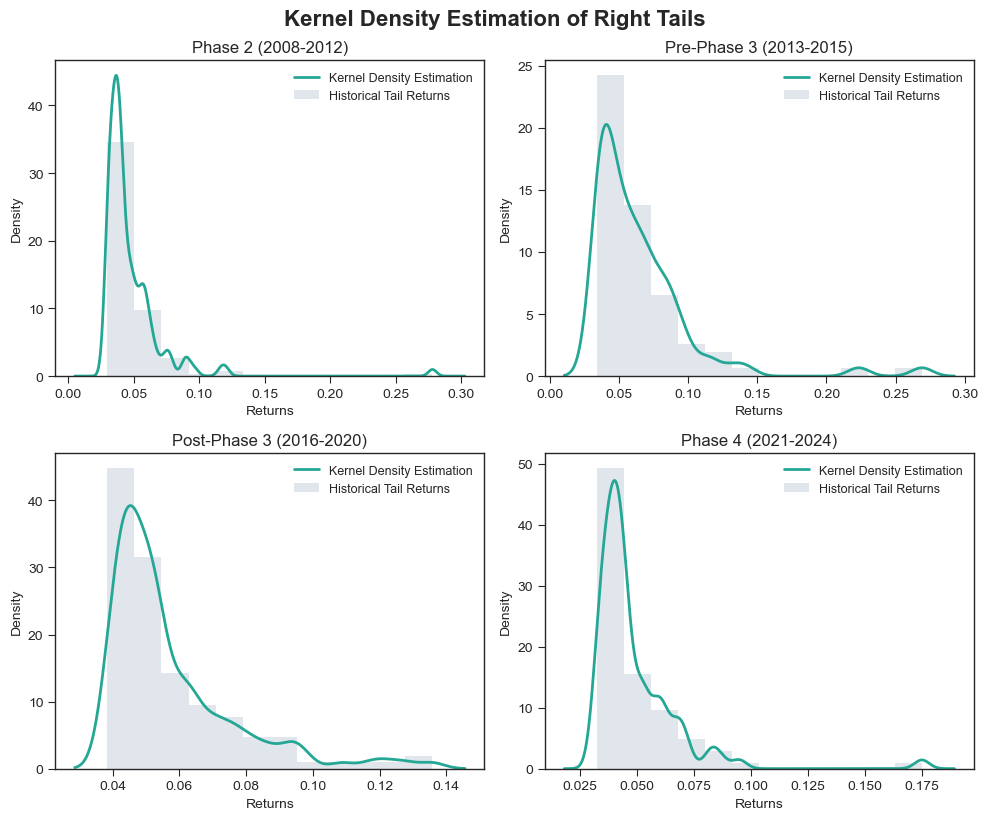

In [28]:
# extreme_returns_df is the filtered return data from the previous step
bw_data, density_data = plot_right_tail_kde(extreme_returns_df, phases, labels)

In [29]:
# Transfer the dictionary into dataframe
bw_df = pd.DataFrame.from_dict(bw_data, orient = 'index') # Ensures phases are rows
styled_bw = bw_df.style.format("{:.6f}")

print("Bandwidths by Different Methods:\n")
display(styled_bw)

Bandwidths by Different Methods:



,Silverman,Sheater-Jones
Phase 2,0.004334,0.003164
Pre-Phase 3,0.009920,0.007644
Post-Phase 3,0.004920,0.003632
Phase 4,0.004054,0.003223


# VaR and ES Plots

Calculation of ES was revised here, using >= instead of >

In [32]:
def calculate_VaR(density_results, phase_labels, confidence_level = 0.50, ncols = 2):
    """
    Calculate and visualise VaR and ES based on KDE density results.
    
    Parameters:
        density_results (dict): Output from the KDE function.
        phase_labels (dict): Mapping for subplot titles.
        confidence_level (float): The quantile level (e.g., 0.95).
        ncols (int): Number of columns for the plot grid.

    Returns:
        pd.DataFrame: A styled table containing VaR and ES for each phase.
    """
    num_phases = len(phases)
    nrows = math.ceil(num_phases / ncols)
    
    fig, axes = plt.subplots(nrows, ncols, figsize = (5 * ncols, 4 * nrows))
    axes_flat = axes.flatten() if num_phases > 1 else [axes]
    
    risk_metrics = []

    for i, (name, kde_result) in enumerate(density_results.items()):
        grid = kde_result['x_grid']
        density = kde_result['density_est']
        
        # Calculate the cumulative distribution function (CDF)
        kde_cdf = np.cumsum(density) / np.sum(density)
        
        # VaR calculation
        idx = np.argmax(kde_cdf >= (1 - confidence_level)) 
        VaR = grid[idx][0]

        # ES calculation
        is_tail = grid[:, 0] >= VaR
        tail_losses = grid[is_tail, 0]
        tail_densities = density[is_tail]
        
        # Conditional expectation: ES = E[X | X > VaR]
        dx = grid[1, 0] - grid[0, 0] # Interval width
        probs = tail_densities * dx # Area (probability) of each segment
        es = np.sum(tail_losses * probs) / np.sum(probs) # Weighted average loss
        
        risk_metrics.append({
            'Phase': name,
            'VaR': VaR,
            'ES': es
        })
        
        ax = axes_flat[i]
        ax.plot(grid[:, 0], density, color = '#25A795', lw = 2, label = 'Kernel Density Estimation')
        
        # Fill the area under the KDE curve where 'is_tail' is True
        ax.fill_between(grid[:, 0], 0, density, where = is_tail, color = '#A2EDDC', alpha = 0.3)
        
        ax.axvline(x = VaR, color = '#262626', linestyle = '--', lw = 1, label = f'95% VaR = {VaR:.6f}')
        ax.axvline(x = es, color = '#262626', linestyle = ':', lw = 1, label = f'ES = {es:.6f}')
        
        ax.set_title(phase_labels.get(name, name), fontsize = 12)
        ax.set_xlabel('Returns')
        ax.set_ylabel('Density')
        ax.legend(fontsize = 8)

    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle(f"VaR & ES Across Phases", fontsize = 16, y = 1, fontweight = 'bold')
    plt.tight_layout()
    plt.show()

    risk_df = pd.DataFrame(risk_metrics).set_index('Phase')
    return risk_df

>**Note on ES calculation:** The Expected Shortfall (ES) was calculated using a conservative boundary condition ($R_{t} \geq \text{VaR}$), ensuring all tail events at the threshold were captured. This represents a minor refinement over the initial thesis implementation to improve numerical stability.

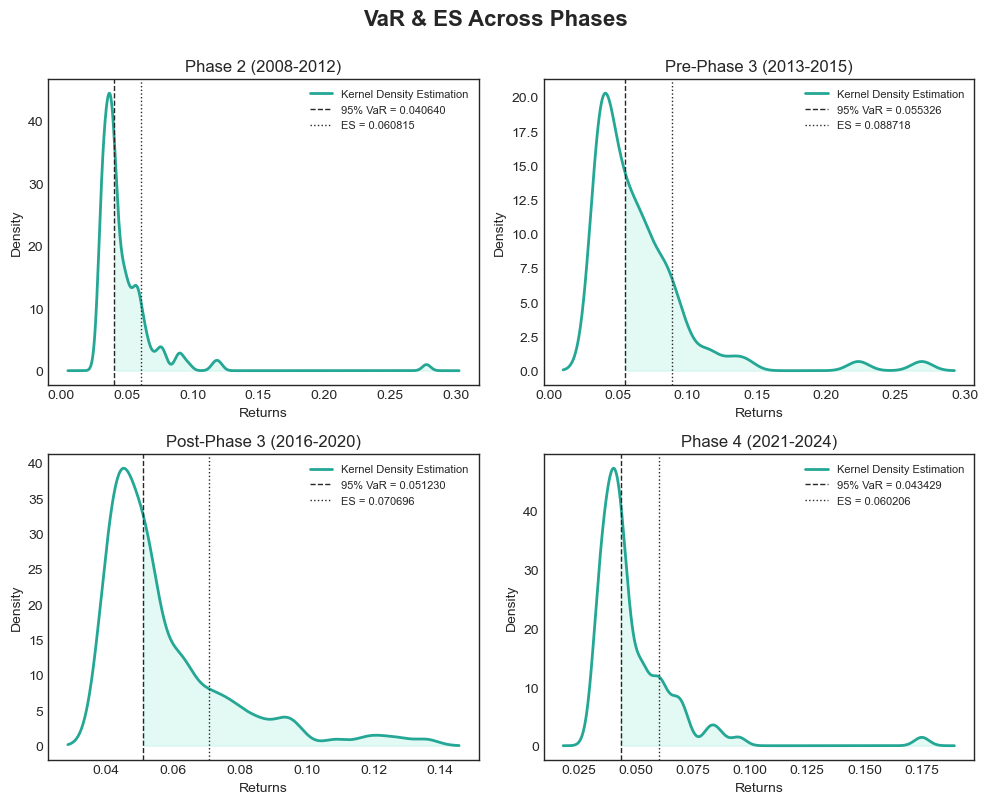

In [33]:
risk_metrics = calculate_VaR(density_data, labels)

In [34]:
print("The 95% VaR and ES of EUA Return across Phases:\n")
risk_metrics.index.name = None

display(risk_metrics)

The 95% VaR and ES of EUA Return across Phases:



,VaR,ES
Phase 2,0.040640,0.060815
Pre-Phase 3,0.055326,0.088718
Post-Phase 3,0.051230,0.070696
Phase 4,0.043429,0.060206


# Kupiec Test

In [35]:
def perform_kupiec_test_df(risk_metrics, df, p_target = 0.05):
    """
    Perform Kupiec's POF backtest using DataFrames.
    
    Parameters:
        risk_metrics (pd.DataFrame): Contains 'Phase' and 'VaR' columns.
        phases_df (pd.DataFrame): Contains 'Phase' and 'Returns' columns for all data.
        p_target (float): Target failure rate (0.05 for 95% VaR).
        
    Returns:
        pd.DataFrame
            A summary table containing:
            - 'Phase': The specific market period being tested.
            - 'N': Total number of observations (trading days) in the phase.
            - 'x': Number of violations (Returns > VaR).
            - 'p_hat': Observed failure rate (x/N).
            - 'LR': Likelihood Ratio test statistic.
            - 'P-Value': Significance level (P-value >= 0.05 indicates the model passes).
            - 'Pass Test': Boolean ('Yes'/'No') based on 5% significance level.
    """
    kupiec_results = []
    
    for phase_name, metrics in risk_metrics.iterrows():
        
        var_threshold = metrics['VaR']
        # Filter raw returns for the specific phase
        phase_returns = df[df['Phase'] == phase_name]['Returns']
        
        # Count actual violations: cases where actual return is greater than estimated VaR 
        x = np.sum(phase_returns > var_threshold)
        
        # Total number of observations (trading days)
        N = len(phase_returns)
        
        # Observed failure rate
        p_hat = x / N if N > 0 else 0
        
        # Calculate Likelihood Ratio (LR) statistics
        # Handle edge cases (x=0 or p_hat=1) to avoid log(0) errors
        if x == 0:
            lr_stat = -2 * np.log((1 - p_target) ** N)
        elif p_hat == 1:
            lr_stat = -2 * np.log(p_target ** N)
        else:
            term_null = ((1 - p_target) ** (N - x)) * (p_target ** x)
            term_alt = ((1 - p_hat) ** (N - x)) * (p_hat ** x)
            lr_stat = -2 * np.log(term_null / term_alt)
        
        # Calculate p-value using Chi-square distribution with df = 1 
        p_value = 1 - stats.chi2.cdf(lr_stat, df=1)
        
        kupiec_results.append({
            'Phase': phase_name,
            'N': N,
            'x': x,
            'p_hat': p_hat,
            'LR': lr_stat,
            'P-Value': p_value,
            'Pass Test': 'Yes' if p_value >= 0.05 else 'No'
        })
    
    return pd.DataFrame(kupiec_results)

In [36]:
kupiec_summary = perform_kupiec_test_df(risk_metrics, carbon_data, p_target = 0.05)
display(kupiec_summary)

,Phase,N,x,p_hat,LR,P-Value,Pass Test
0,Phase 2,1285,60,0.046693,0.302320,0.582432,Yes
1,Pre-Phase 3,774,39,0.050388,0.002442,0.960587,Yes
2,Post-Phase 3,1287,63,0.048951,0.030012,0.862463,Yes
3,Phase 4,869,42,0.048331,0.051482,0.820505,Yes


>**Note:** To pass the Kupiec Test, the LR statistic must be less than 3.841. All reported phases met this criterion, indicating high model reliability.

# Tail Risk Plot

In [37]:
def calculate_es_to_var_ratio(risk_df, var = 'VaR', es = 'ES'):
    """
    Calculate the ES-to-VaR ratio.
    
    Parameters:
        risk_df (pd.DataFrame): A DataFrame expected to have columns for VaR and ES.
        var (str, optional): The name of the column representing Value-at-Risk (default to 'VaR').
        es (str, optional): The name of the column representing Expected Shortfall (default to 'ES').
        
    Returns:
        pd.DataFrame: The original DataFrame with an additional 'ES-to-VaR' column containing the calculated ratios.       
    """
    risk_df['ES-to-VaR'] = risk_df[es] / risk_df[var]
    
    return risk_df 

In [38]:
risk_metrics = calculate_es_to_var_ratio(risk_metrics)
display(risk_metrics.style.format("{:.6f}"))

,VaR,ES,ES-to-VaR
Phase 2,0.040640,0.060815,1.496426
Pre-Phase 3,0.055326,0.088718,1.603552
Post-Phase 3,0.051230,0.070696,1.379970
Phase 4,0.043429,0.060206,1.386295


In [39]:
def plot_risk_analysis(risk_df):
    """
    Generate side-by-side plots to visualise the VaR, ES and ES-to-VaR ratio across different market phases. 
    The function creates two subplots:
    1. A grouped bar chart comparing VaR and ES.
    2. A line plot of the ES-to-VaR ratio, which serves as a proxy for tail thickness (kurtosis). 
       A horizontal line representing the mean ratio is included for benchmarking.

    Parameters:
        risk_df(pd.DataFrame): A DataFrame containing risk metrics. 
            - The Index should be the phase names (e.g., 'Phase 2', 'Phase 3').
            - Required columns: 'VaR', 'ES', and 'ES-to-VaR'.
            - Note: 'ES-to-VaR' must be numeric (float) for plotting.
    
    Returns:
        None: This function generates a Matplotlib figure directly.
    """ 
    phases = risk_df.index.tolist()
    n_phases = len(phases)
    x_pos = np.arange(n_phases)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (14, 5))
    
    # Left plot: VaR vs. ES
    # PLot VaR bars: offset to the left by half the width for side-by-side plotting
    bar_width = 0.35
    ax1.bar(x_pos - bar_width / 2, risk_df['VaR'], width = bar_width, 
            color = '#53687B', label = 'Value-at-Risk (95%)', alpha = 0.9)
    
    # Plot ES bars: offset to the right by half the width
    ax1.bar(x_pos + bar_width / 2, risk_df['ES'], width = bar_width, 
            color = '#29B4B6', label = 'Expected Shortfall', alpha = 0.9)
    
    ax1.set_xticks(x_pos, labels = phases, fontsize = 12)
    ax1.set_ylabel('Returns', fontsize = 12)
    ax1.set_title('VaR vs. Expected Shortfall across Phases', fontweight='bold',
                 fontsize = 16, pad = 15)
    ax1.grid(axis = 'y', linestyle = '--', alpha = 0.3)
    ax1.legend(frameon = True)

    # Right plot: Tail Thickness
    ax2.plot(phases, risk_df['ES-to-VaR'], color = '#F0776D', marker = 'o', 
             linewidth = 2, markersize = 8, label = 'ES-to-VaR Ratio')
    
    # Add mean ratio
    mean_ratio = risk_df['ES-to-VaR'].mean()
    ax2.axhline(mean_ratio, color = '#7F8C8D', linestyle = '--', alpha = 0.6, 
                label = f'Mean: {mean_ratio:.6f}')

    ax2.set_xticks(x_pos, labels = phases, fontsize = 12)
    ax2.set_ylabel('Ratio', fontsize = 12)
    ax2.set_title('Tail Thickness (ES-to-VaR) across Phases', fontweight='bold', 
                  fontsize = 16, pad = 15)
    ax2.grid(axis = 'y', linestyle = '--', alpha = 0.3)
    ax2.legend(frameon = True)

    plt.tight_layout()
    plt.show()

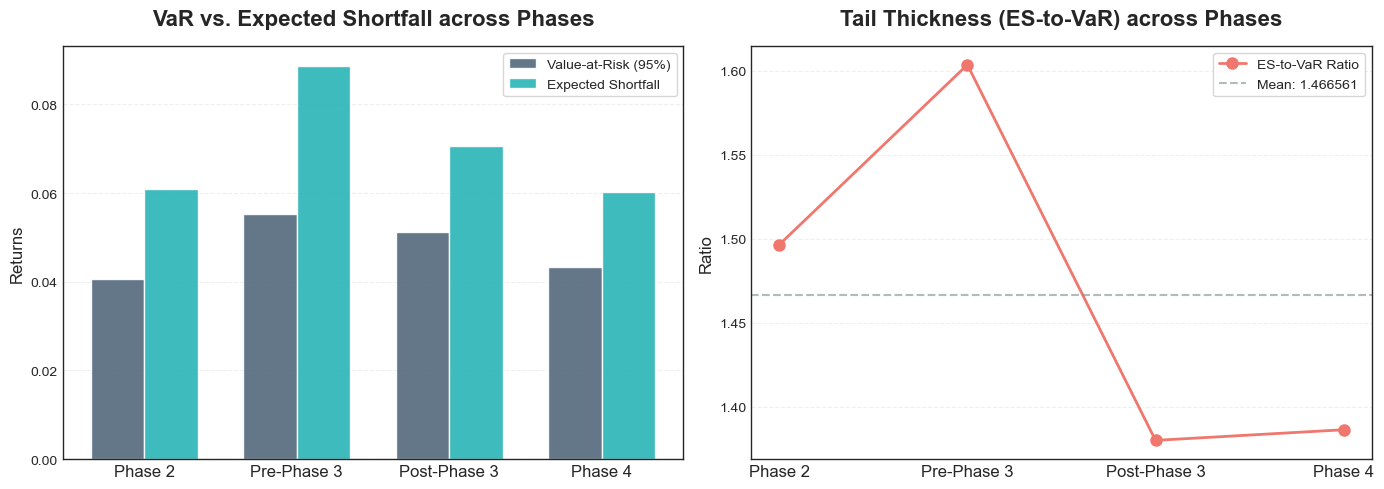

In [40]:
plot_risk_analysis(risk_metrics)